____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD, compute_mean_square, drifters_sources, assign_attrs, compute_mean_square_groupby

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Surface

In [3]:
DAK = []
AK = ['swot2kmnaive', 'L4noswotregional', 'L4noswotglobal', 'L4withswot']
for alti_key in AK:  
    f = sorted(glob(os.path.join(zarr_dir, 'save','10days_time_to_swot', f'save_savedeltaT_10days_{alti_key}*_surface.nc')))
    print(f)
    DAK.append(xr.open_mfdataset(f))


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive_LF_surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive__surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_swot2kmnaive_inertial_surface.nc']


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotregional_LF_surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotregional__surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotregional_inertial_surface.nc']


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotglobal_LF_surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotglobal__surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4noswotglobal_inertial_surface.nc']


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))


['/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot_LF_surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot__surface.nc', '/Users/mdemol/DATA_MED_COLOC/save/10days_time_to_swot/save_savedeltaT_10days_L4withswot_inertial_surface.nc']


/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))
/var/folders/fn/z858c2qj1lz65xr0z5mdvbf40000gp/T/ipykernel_50293/2331315562.py:6: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  DAK.append(xr.open_mfdataset(f))


In [4]:
D0 = []
for i in range(len(AK)):
    D = []
    for c in DAK[i].id_comb.values :
        dff = DAK[i].sel(id_comb=c).to_dataframe().reset_index().set_index('row_number')
        D.append(compute_mean_square_groupby(dff, groupby = 'time_to_swot_1h', compute_error = 'centrallimit'))
        print(c)
    D0.append(xr.concat(D, pd.Index([ 'LF','All', 'Inertial'], name = 'frequency_band')))
dss = xr.concat(D0, pd.Index(AK , name = 'alti_key'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}

dss['sX'] = dss[X[0]]
for x in X[1:]:
    dss['sX']= dss['sX']+dss[x]

dss['time_to_swot_1h'] = (dss.time_to_swot_1h/24).assign_attrs(long_name = 'Drifter-altimetry time gap', units='day')

nofilter_LF__swot2kmnaive_etaf__rio_0era5
nofilter___swot2kmnaive_etaf__rio_0era5
nofilter_inertial__swot2kmnaive_etaf__rio_0era5
nofilter_LF__L4noswotregional_adt__rio_0era5
nofilter___L4noswotregional_adt__rio_0era5
nofilter_inertial__L4noswotregional_adt__rio_0era5
nofilter_LF__L4noswotglobal_adt__rio_0era5
nofilter___L4noswotglobal_adt__rio_0era5
nofilter_inertial__L4noswotglobal_adt__rio_0era5
nofilter_LF__L4withswot_adt__rio_0era5
nofilter___L4withswot_adt__rio_0era5
nofilter_inertial__L4withswot_adt__rio_0era5


In [5]:
dss['alti_key'] = [ 'L3-2km-SWOT','L4-regional-noSWOT','L4-global-noSWOT', 'L4-SWOT',]

In [6]:
dss['frequency_band'] = [ 'LF','All', 'Inertial']

In [7]:
dss.to_netcdf(os.path.join(zarr_dir, 'save', 'savedeltaT_all_MS_surface.nc'))

___________
# If already computed 

In [20]:
dss = xr.open_dataset(os.path.join(zarr_dir, 'save','10days_time_to_swot', 'savedeltaT_all_MS_surface.nc'))


X = ['X_acc_cor','X_acc_ggd','X_acc_wd','X_cor_ggd','X_cor_wd','X_ggd_wd']
xstyle = {l.replace('X_', '') : dict(color=c0[l.split('_')[1]], marker="x", markeredgecolor=c0[l.split('_')[2]], markersize=3) for l in X}


In [21]:
def plot_error(df, x, v, ax, suf = 'ber__'):
    ax.fill_between(
        df[x], df[v] - df[suf + v], df[v] + df[suf + v], color="silver"
    )
def low_filter(ds, T=2, cutoff = [0.9], vars_ = ['B_ggd', 'E_ggd']+X):
    from scipy import signal
    from scipy.signal import filtfilt
    from scipy.integrate import cumulative_trapezoid
    from scipy.optimize import minimize

    pass_zero = True
    # coefficients
    dt = 1/24  # 1h in days
    numtaps = int(T / dt)
    pass_zero = True
    # filter
    dss = ds.fillna(0)
    taps = signal.firwin(numtaps, cutoff=cutoff, pass_zero=pass_zero, fs=1 / dt, scale=True)
    for v in vars_ : 
        dss[v] = xr.DataArray(
            filtfilt(taps, 1, dss[v]),
            dims=["alti_key", "frequency_band", "time_to_swot_1h"],
            )
    return dss
dsd = low_filter(dss, cutoff = 0.3)    


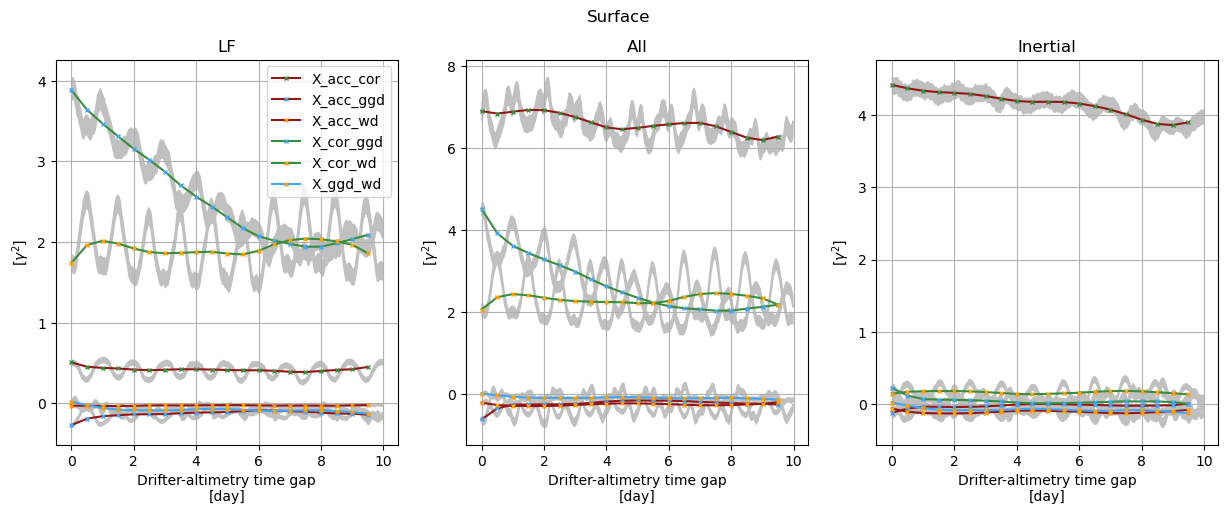

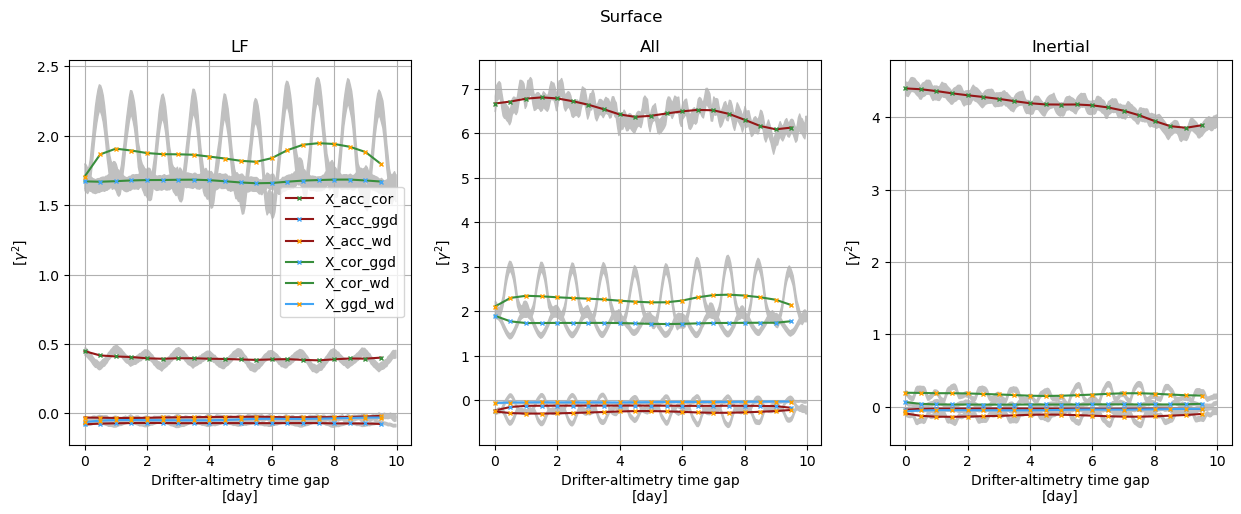

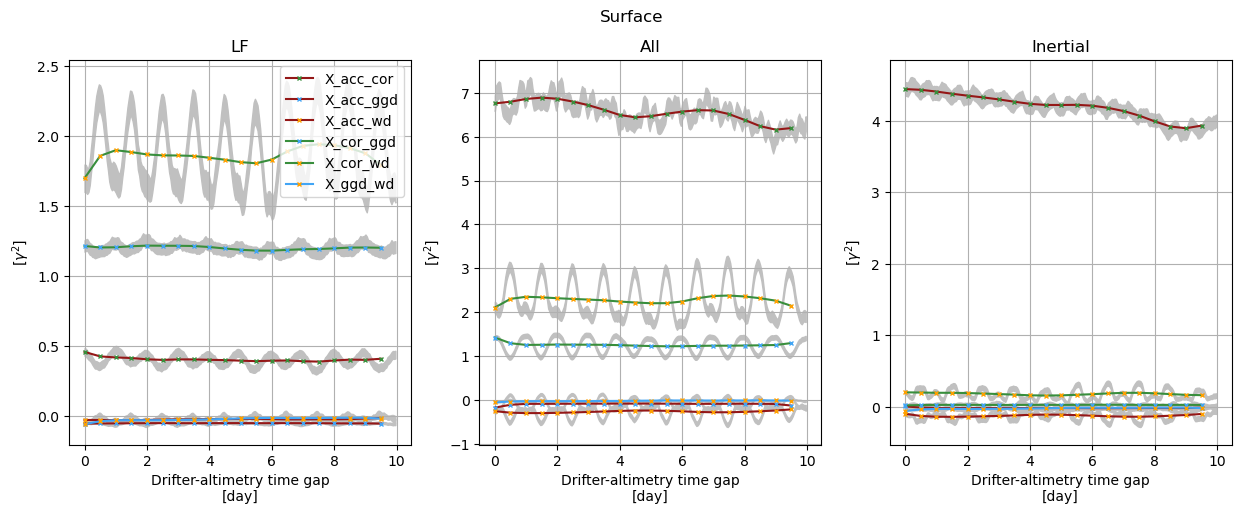

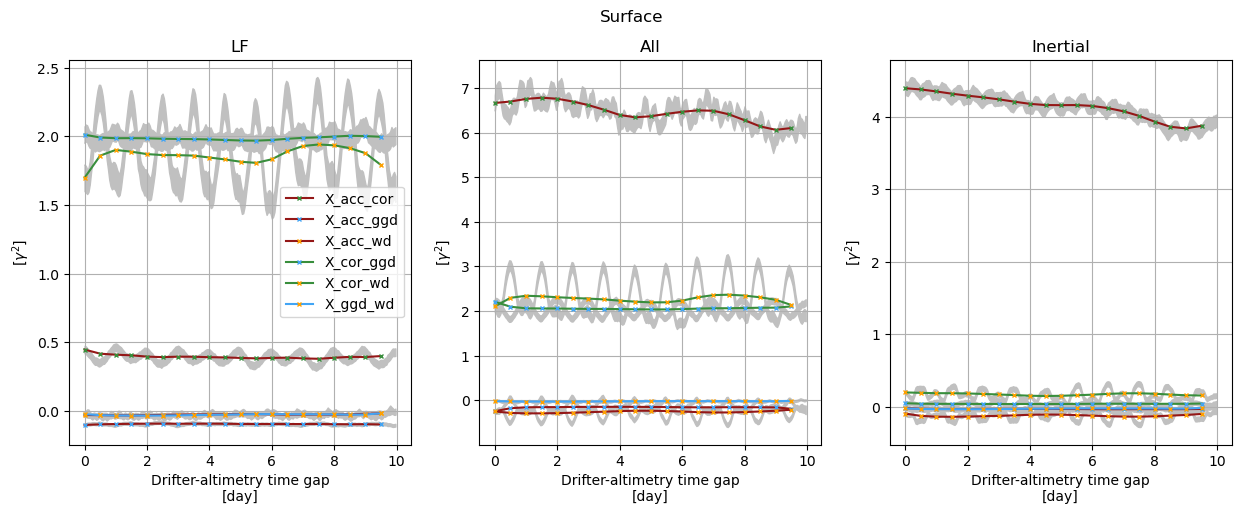

In [22]:
for al in dss.alti_key.values : 
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)
    i=0
    for sp in dss.frequency_band.values : 
        ax=axs[i]
        for x in X :
            #dss_.sel(frequency_band = sp)[x].plot(label=x, **xstyle[x.replace('X_', '')], ax=ax)
            dsd_.sel(frequency_band = sp).isel(time_to_swot_1h= slice(0, None, 12))[x].plot(label=x,**xstyle[x.replace('X_', '')], ax=ax)
            plot_error(dss_.sel(frequency_band = sp),'time_to_swot_1h', x, ax, suf = 'ser__')
        ax.set_title(sp)
        
        #dss_.sel(frequency_band = sp).sX.plot(c='k', label = r'$\sum X_{ij}$', ax=ax)
        i+=1
    
    axs[0].legend()
    
    for ax in axs : 
        ax.grid()
        ax.set_ylabel(r'[$\gamma^2$]')

    fig.suptitle('Surface')


Text(0.5, 0.98, 'Surface')

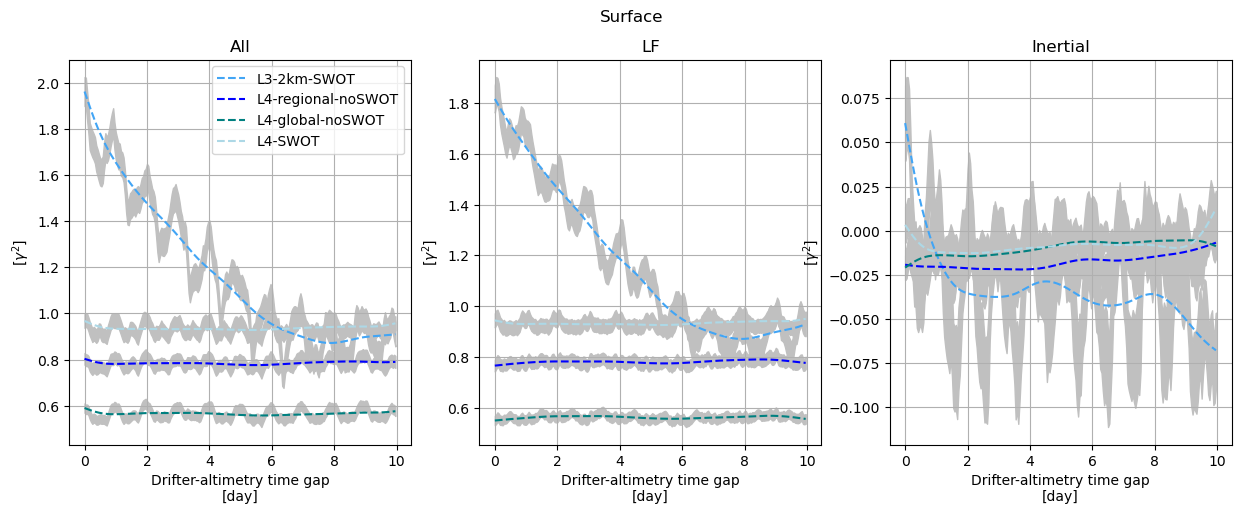

In [12]:

al_color = {'L3-250m-SWOT':'navy', 'L3-2km-SWOT':c0['ggd'],'L4-regional-noSWOT' :'b','L4-global-noSWOT':'teal', 'L4-SWOT':'lightblue'}

fig, axs = plt.subplots(1, 3, figsize=(15,5), frameon=False)#, sharey=True)

for al in dss.alti_key.values :
    dss_ = dss.sel(alti_key =al)    
    dsd_ = dsd.sel(alti_key =al)
    
    for v in ['ggd'] :
        #dss_.sel(frequency_band = 'All')['B_'+v].plot( c = al_color[al], ax=axs[0])
        #dss_.sel(frequency_band = 'LF')['B_'+v].plot( c = al_color[al], ax=axs[1])
        #dss_.sel(frequency_band = 'Inertial')['B_'+v].plot( c = al_color[al], ax=axs[2])
        dsd_.sel(frequency_band = 'All')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[0])
        dsd_.sel(frequency_band = 'LF')['B_'+v].plot(label=al, c = al_color[al], ls='--', ax=axs[1])
        dsd_.sel(frequency_band = 'Inertial')['B_'+v].plot( label=al, c = al_color[al], ls='--', ax=axs[2])
        plot_error(dss_.sel(frequency_band = 'All'),'time_to_swot_1h','B_'+v, axs[0], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'LF'),'time_to_swot_1h', 'B_'+v, axs[1], suf = 'ser__')
        plot_error(dss_.sel(frequency_band = 'Inertial'),'time_to_swot_1h', 'B_'+v, axs[2], suf = 'ser__')
        
    #dss.sel(frequency_band = 'All').sX.plot(c='k', label = r'$\sum X_{ij}$', ax=axs[0])
    #dss.sel(frequency_band = 'LF').sX.plot(c='k', ax=axs[1])
    #dss.sel(frequency_band = 'Inertial').sX.plot(c='k', ax=axs[2])
    
axs[0].legend()

axs[0].set_title('All')
axs[1].set_title('LF')
axs[2].set_title('Inertial')

for ax in axs : 
    ax.grid()
    ax.set_ylabel(r'[$\gamma^2$]')
    #ax.set_xlabel('Drifter-altimetry time gap [h]')

fig.suptitle('Surface')


1.2890950082486392


/opt/anaconda3/envs/equinox/lib/python3.10/site-packages/xrscipy/signal/spectral.py:308: UserWarning: nperseg = 256 is greater than input length  = 240, using nperseg = 240
  f, t, Pxy = _spectral_helper(


Text(0.5, 1.0, '')

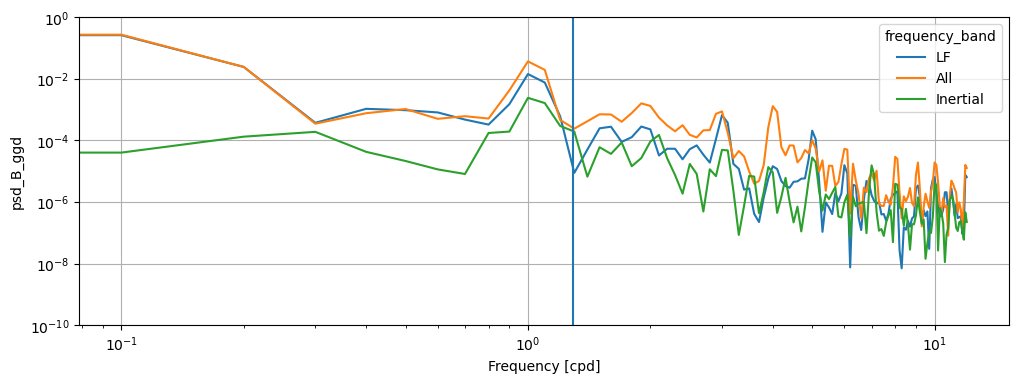

In [23]:
import xrscipy.signal.extra as dsp_extra
dsd = dsp_extra.psd(dss.B_ggd, dim="time_to_swot_1h")
fig, ax = plt.subplots(1, 1, figsize=(12, 4), frameon=False)
fc = pyn.geo.coriolis(40) * 86400 / 2 / np.pi
print(fc)
dsd.sel(alti_key = 'L3-2km-SWOT').plot(ax=ax, hue='frequency_band')
ax.axvline(abs(fc))
ax.set_xlabel("Frequency [cpd]")
ax.set_xscale("log")
ax.set_yscale("log")
ax.grid()
ax.set_ylim(1e-10, 1e0)
#ax.set_xlim(-24 * 60 / 30 / 2, 24 * 60 / 30 / 2)
ax.set_title("")
